In [1]:
import numpy as np
import pandas as pd

from sklearn.model_selection import KFold, cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler, OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.svm import SVR

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error

from sklearn.decomposition import PCA
from sklearn.linear_model import Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor, GradientBoostingRegressor, AdaBoostRegressor
from sklearn.neural_network import MLPRegressor
from xgboost import XGBRegressor

In [2]:
df = pd.read_csv('gurgaon_properties_post_feature_selection_v2.csv')

In [9]:
df.head()

,property_type,sector,price,bedRoom,bathroom,balcony,agePossession,built_up_area,servant room,store room,furnishing_type,luxury_category,floor_category
0,flat,sector 36,0.82,3.0,2.0,2,New Property,850.0,0.0,0.0,0.0,Low,Low Floor
1,flat,sector 89,0.95,2.0,2.0,2,New Property,1226.0,1.0,0.0,0.0,Low,Mid Floor
2,flat,sohna road,0.32,2.0,2.0,1,New Property,1000.0,0.0,0.0,0.0,Low,High Floor
3,flat,sector 92,1.60,3.0,4.0,3+,Relatively New,1615.0,1.0,0.0,1.0,High,Mid Floor
4,flat,sector 102,0.48,2.0,2.0,1,Relatively New,582.0,0.0,1.0,0.0,High,Mid Floor


In [3]:
df['furnishing_type'].value_counts()

furnishing_type
0.0    2349
1.0    1018
2.0     187
Name: count, dtype: int64

In [4]:
# 0 -> unfurnished
# 1 -> semifurnished
# 2 -> furnished
df['furnishing_type'] = df['furnishing_type'].replace({0.0:'unfurnished',1.0:'semifurnished',2.0:'furnished'})

In [5]:
df.head()

,property_type,sector,price,bedRoom,bathroom,balcony,agePossession,built_up_area,servant room,store room,furnishing_type,luxury_category,floor_category
0,flat,sector 36,0.82,3.0,2.0,2,New Property,850.0,0.0,0.0,unfurnished,Low,Low Floor
1,flat,sector 89,0.95,2.0,2.0,2,New Property,1226.0,1.0,0.0,unfurnished,Low,Mid Floor
2,flat,sohna road,0.32,2.0,2.0,1,New Property,1000.0,0.0,0.0,unfurnished,Low,High Floor
3,flat,sector 92,1.60,3.0,4.0,3+,Relatively New,1615.0,1.0,0.0,semifurnished,High,Mid Floor
4,flat,sector 102,0.48,2.0,2.0,1,Relatively New,582.0,0.0,1.0,unfurnished,High,Mid Floor


In [6]:
X = df.drop(columns=['price'])
y = df['price']

In [7]:
# Applying the log1p transformation to the target variable
y_transformed = np.log1p(y)

### Ordinal Encoding

In [8]:
columns_to_encode = ['property_type','sector', 'balcony', 'agePossession', 'furnishing_type', 'luxury_category', 'floor_category']

In [10]:
# Creating a column transformer for preprocessing
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), ['bedRoom', 'bathroom', 'built_up_area', 'servant room', 'store room']),
        ('cat', OrdinalEncoder(), columns_to_encode)
    ], 
    remainder='passthrough'
)

In [11]:
# Creating a pipeline
pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', LinearRegression())
])

In [12]:
# K-fold cross-validation
kfold = KFold(n_splits=10, shuffle=True, random_state=42)
scores = cross_val_score(pipeline, X, y_transformed, cv=kfold, scoring='r2')

In [18]:
scores.mean(),scores.std()

(np.float64(0.7363096633436828), np.float64(0.03238005754429941))

In [14]:
X_train, X_test, y_train, y_test = train_test_split(X,y_transformed,test_size=0.2,random_state=42)

In [15]:
pipeline.fit(X_train,y_train)

,steps,"[('preprocessor', ...), ('regressor', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [21]:
y_pred = pipeline.predict(X_test)

In [22]:
y_pred = np.expm1(y_pred)

In [23]:
mean_absolute_error(np.expm1(y_test),y_pred)

0.9463822160089357

In [20]:
def scorer(model_name, model):
    
    output = []
    
    output.append(model_name)
    
    pipeline = Pipeline([
        ('preprocessor', preprocessor),
        ('regressor', model)
    ])
    
    # K-fold cross-validation
    kfold = KFold(n_splits=10, shuffle=True, random_state=42)
    scores = cross_val_score(pipeline, X, y_transformed, cv=kfold, scoring='r2')
    
    output.append(scores.mean())
    
    X_train, X_test, y_train, y_test = train_test_split(X,y_transformed,test_size=0.2,random_state=42)
    
    pipeline.fit(X_train,y_train)
    
    y_pred = pipeline.predict(X_test)
    
    y_pred = np.expm1(y_pred)
    
    output.append(mean_absolute_error(np.expm1(y_test),y_pred))
    
    return output
    

In [21]:
model_dict = {
    'linear_reg':LinearRegression(),
    'svr':SVR(),
    'ridge':Ridge(),
    'LASSO':Lasso(),
    'decision tree': DecisionTreeRegressor(),
    'random forest':RandomForestRegressor(),
    'extra trees': ExtraTreesRegressor(),
    'gradient boosting': GradientBoostingRegressor(),
    'adaboost': AdaBoostRegressor(),
    'mlp': MLPRegressor(),
    'xgboost':XGBRegressor()
}

In [22]:
model_output = []
for model_name,model in model_dict.items():
    model_output.append(scorer(model_name, model))

In [23]:
model_output

[['linear_reg', np.float64(0.7363096633436828), 0.9463822160089357],
 ['svr', np.float64(0.7642012011196353), 0.847263647348393],
 ['ridge', np.float64(0.7363125343993552), 0.9463387741853369],
 ['LASSO', np.float64(0.05943378064493572), 1.528905986892753],
 ['decision tree', np.float64(0.7658648050493427), 0.7387887514884974],
 ['random forest', np.float64(0.8813479000091646), 0.53151148343142],
 ['extra trees', np.float64(0.8680613574741031), 0.5486530036904793],
 ['gradient boosting', np.float64(0.8725503427240111), 0.5760506721008158],
 ['adaboost', np.float64(0.7532842036425655), 0.8351061484242843],
 ['mlp', np.float64(0.8137144515510603), 0.6665034286896747],
 ['xgboost', np.float64(0.8894876835260124), 0.5040475141482346]]

In [24]:
model_df = pd.DataFrame(model_output, columns=['name','r2','mae'])

In [25]:
model_df.sort_values(['mae'])

,name,r2,mae
10,xgboost,0.889488,0.504048
5,random forest,0.881348,0.531511
6,extra trees,0.868061,0.548653
7,gradient boosting,0.872550,0.576051
9,mlp,0.813714,0.666503
4,decision tree,0.765865,0.738789
8,adaboost,0.753284,0.835106
1,svr,0.764201,0.847264
2,ridge,0.736313,0.946339
0,linear_reg,0.736310,0.946382


In [30]:
import xgboost as xgb
import optuna
import numpy as np

from sklearn.metrics import mean_absolute_error

# =========================================================
# HANDLE CATEGORICAL COLUMNS
# =========================================================

X_train = X_train.copy()
X_test = X_test.copy()

cat_cols = [
    'property_type',
    'sector',
    'balcony',
    'agePossession',
    'furnishing_type',
    'luxury_category',
    'floor_category'
]

for col in cat_cols:
    X_train[col] = X_train[col].astype('category')
    X_test[col] = X_test[col].astype('category')

# =========================================================
# OPTUNA OBJECTIVE FUNCTION
# =========================================================

def objective(trial):

    params = {

        # Core Parameters
        'objective': 'reg:squarederror',
        'tree_method': 'hist',
        'enable_categorical': True,

        # Boosting Parameters
        'n_estimators': 2000,
        'learning_rate': trial.suggest_float(
            'learning_rate',
            0.01,
            0.1,
            log=True
        ),

        'max_depth': trial.suggest_int(
            'max_depth',
            4,
            8
        ),

        'min_child_weight': trial.suggest_int(
            'min_child_weight',
            1,
            10
        ),

        'subsample': trial.suggest_float(
            'subsample',
            0.7,
            0.9
        ),

        'colsample_bytree': trial.suggest_float(
            'colsample_bytree',
            0.7,
            0.9
        ),

        # Regularization
        'reg_alpha': trial.suggest_float(
            'reg_alpha',
            1e-8,
            1.0,
            log=True
        ),

        'reg_lambda': trial.suggest_float(
            'reg_lambda',
            1e-8,
            1.0,
            log=True
        ),

        # Misc
        'early_stopping_rounds': 50,
        'random_state': 42,
        'n_jobs': -1
    }

    # =====================================================
    # MODEL
    # =====================================================

    model = xgb.XGBRegressor(**params)

    model.fit(
        X_train,
        y_train,

        eval_set=[(X_test, y_test)],

        verbose=False
    )

    # =====================================================
    # PREDICTIONS
    # =====================================================

    preds = model.predict(X_test)

    # =====================================================
    # MAE
    # =====================================================

    mae = mean_absolute_error(
        np.expm1(y_test),
        np.expm1(preds)
    )

    return mae

# =========================================================
# CREATE OPTUNA STUDY
# =========================================================

study = optuna.create_study(
    direction='minimize',
    study_name='XGBoost_RealEstate_Optimization'
)

# =========================================================
# RUN OPTIMIZATION
# =========================================================

study.optimize(
    objective,
    n_trials=50
)

# =========================================================
# BEST RESULTS
# =========================================================

print("\n====================================")
print(f"Best MAE: {study.best_value:.4f}")

print("\nBest Parameters:")

for key, value in study.best_params.items():
    print(f"{key}: {value}")

print("====================================")

# =========================================================
# FINAL MODEL TRAINING
# =========================================================

best_params = study.best_params

best_params.update({

    'objective': 'reg:squarederror',
    'tree_method': 'hist',
    'enable_categorical': True,

    'n_estimators': 3000,
    'early_stopping_rounds': 50,

    'random_state': 42,
    'n_jobs': -1
})

final_xgb_model = xgb.XGBRegressor(**best_params)

final_xgb_model.fit(

    X_train,
    y_train,

    eval_set=[(X_test, y_test)],

    verbose=100
)

# =========================================================
# FINAL RESULTS
# =========================================================

final_preds = final_xgb_model.predict(X_test)

final_mae = mean_absolute_error(
    np.expm1(y_test),
    np.expm1(final_preds)
)

print("\n====================================")
print(f"Final MAE: {final_mae:.4f}")
print(f"Best Iteration: {final_xgb_model.best_iteration}")
print("====================================")

[I 2026-05-14 13:29:41,913] A new study created in memory with name: XGBoost_RealEstate_Optimization
[I 2026-05-14 13:29:48,710] Trial 0 finished with value: 0.45154740348060085 and parameters: {'learning_rate': 0.06428218496826911, 'max_depth': 7, 'min_child_weight': 4, 'subsample': 0.738920453894695, 'colsample_bytree': 0.7917103181651046, 'reg_alpha': 1.043655339346768e-07, 'reg_lambda': 0.21443021800773054}. Best is trial 0 with value: 0.45154740348060085.
[I 2026-05-14 13:30:34,572] Trial 1 finished with value: 0.46621541434953984 and parameters: {'learning_rate': 0.06347752449787887, 'max_depth': 6, 'min_child_weight': 10, 'subsample': 0.8410250048505202, 'colsample_bytree': 0.7459096449374735, 'reg_alpha': 4.337942568374689e-08, 'reg_lambda': 1.6543546320006944e-05}. Best is trial 0 with value: 0.45154740348060085.
[I 2026-05-14 13:30:54,581] Trial 2 finished with value: 0.45567017131381565 and parameters: {'learning_rate': 0.016637296850843863, 'max_depth': 8, 'min_child_weight


Best MAE: 0.4170

Best Parameters:
learning_rate: 0.03776515177315999
max_depth: 8
min_child_weight: 1
subsample: 0.7722773914713587
colsample_bytree: 0.8857050420730359
reg_alpha: 3.2471719103366384e-06
reg_lambda: 1.5702170540827246e-08
[0]	validation_0-rmse:0.54141
[100]	validation_0-rmse:0.15493
[200]	validation_0-rmse:0.15226
[253]	validation_0-rmse:0.15261

Final MAE: 0.4170
Best Iteration: 203


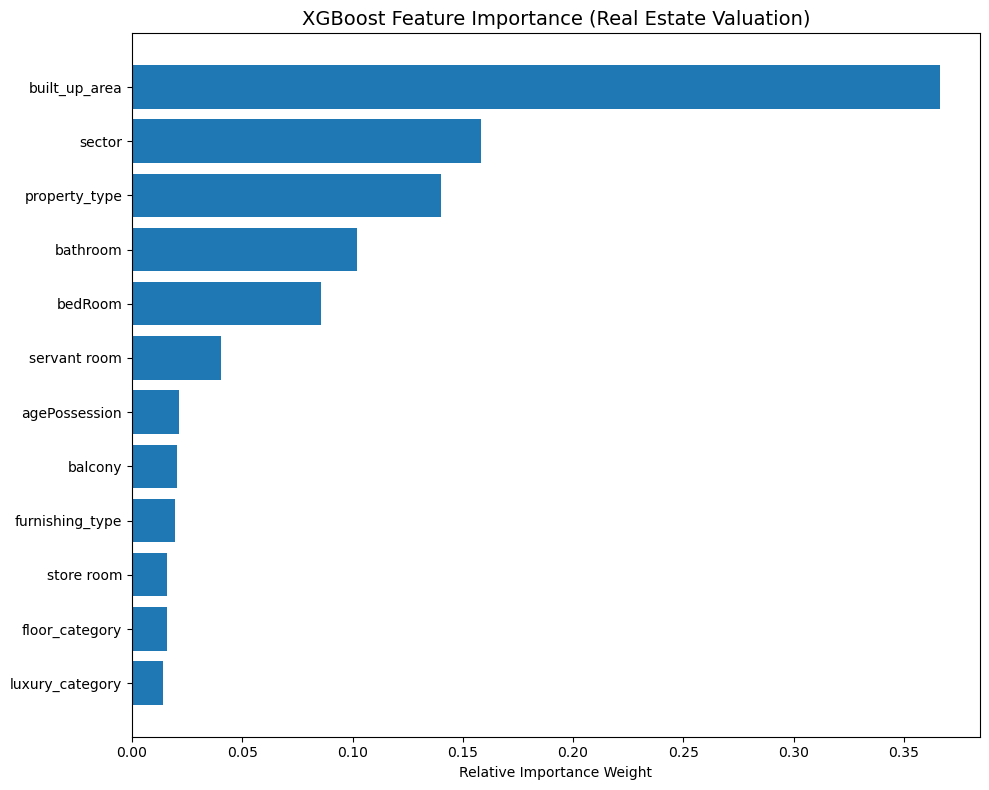

In [31]:
import matplotlib.pyplot as plt

# Get feature importances from your final model
importances = final_xgb_model.feature_importances_
feature_names = X_train.columns

# Sort them
sorted_idx = importances.argsort()

# Plot
plt.figure(figsize=(10, 8))
plt.barh(range(len(sorted_idx)), importances[sorted_idx], align='center', color='#1f77b4')
plt.yticks(range(len(sorted_idx)), np.array(feature_names)[sorted_idx])
plt.title('XGBoost Feature Importance (Real Estate Valuation)', fontsize=14)
plt.xlabel('Relative Importance Weight')
plt.tight_layout()
plt.show()

In [32]:
from sklearn.metrics import r2_score
import numpy as np

# 1. Generate predictions using your final trained model
preds = final_xgb_model.predict(X_test)

# 2. Calculate R2 Score (reverting the log transformation with expm1)
r2 = r2_score(np.expm1(y_test), np.expm1(preds))

print(f"R² Score: {r2:.4f}")

R² Score: 0.8766


### OneHotEncoding

In [9]:
# Creating a column transformer for preprocessing
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), ['bedRoom', 'bathroom', 'built_up_area', 'servant room', 'store room']),
        ('cat', OrdinalEncoder(), columns_to_encode),
        ('cat1',OneHotEncoder(drop='first'),['sector','agePossession','furnishing_type'])
    ], 
    remainder='passthrough'
)

In [11]:
# Creating a pipeline
pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', LinearRegression())
])

In [12]:
# K-fold cross-validation
kfold = KFold(n_splits=10, shuffle=True, random_state=42)
scores = cross_val_score(pipeline, X, y_transformed, cv=kfold, scoring='r2')

In [29]:
scores.mean()

np.float64(0.8546096323539831)

In [30]:
scores.std()

np.float64(0.015996824102062494)

In [14]:
X_train, X_test, y_train, y_test = train_test_split(X,y_transformed,test_size=0.2,random_state=42)

In [32]:
pipeline.fit(X_train,y_train)

,steps,"[('preprocessor', ...), ('regressor', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...), ...]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [33]:
y_pred = pipeline.predict(X_test)

In [34]:
y_pred = np.expm1(y_pred)

In [35]:
mean_absolute_error(np.expm1(y_test),y_pred)

0.6497673463840029

In [13]:
def scorer(model_name, model):
    
    output = []
    
    output.append(model_name)
    
    pipeline = Pipeline([
        ('preprocessor', preprocessor),
        ('regressor', model)
    ])
    
    # K-fold cross-validation
    kfold = KFold(n_splits=10, shuffle=True, random_state=42)
    scores = cross_val_score(pipeline, X, y_transformed, cv=kfold, scoring='r2')
    
    output.append(scores.mean())
    
    X_train, X_test, y_train, y_test = train_test_split(X,y_transformed,test_size=0.2,random_state=42)
    
    pipeline.fit(X_train,y_train)
    
    y_pred = pipeline.predict(X_test)
    
    y_pred = np.expm1(y_pred)
    
    output.append(mean_absolute_error(np.expm1(y_test),y_pred))
    
    return output
    

In [37]:
model_dict = {
    'linear_reg':LinearRegression(),
    'svr':SVR(),
    'ridge':Ridge(),
    'LASSO':Lasso(),
    'decision tree': DecisionTreeRegressor(),
    'random forest':RandomForestRegressor(),
    'extra trees': ExtraTreesRegressor(),
    'gradient boosting': GradientBoostingRegressor(),
    'adaboost': AdaBoostRegressor(),
    'mlp': MLPRegressor(),
    'xgboost':XGBRegressor()
}

In [38]:
model_output = []
for model_name,model in model_dict.items():
    model_output.append(scorer(model_name, model))

c:\Users\Soham\anaconda3\envs\myenv\lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


In [39]:
model_df = pd.DataFrame(model_output, columns=['name','r2','mae'])

In [40]:
model_df.sort_values(['mae'])

,name,r2,mae
6,extra trees,0.893710,0.464123
10,xgboost,0.895850,0.493456
5,random forest,0.891150,0.509630
9,mlp,0.874948,0.553618
7,gradient boosting,0.876612,0.567897
0,linear_reg,0.854610,0.649767
2,ridge,0.854685,0.652853
4,decision tree,0.808241,0.695814
8,adaboost,0.755705,0.818513
1,svr,0.769741,0.834124


In [15]:
import optuna
from sklearn.ensemble import ExtraTreesRegressor
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_val_score, KFold
from sklearn.metrics import mean_absolute_error
from sklearn.compose import make_column_selector
import numpy as np

# ---------------------------------------------------------
# 1. DEFINE A ROBUST PREPROCESSOR
# ---------------------------------------------------------
# This version automatically finds all object/category columns 
# so nothing "slips through" as a string.
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer

# Let's create a fresh, safe preprocessor for this model
robust_preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), make_column_selector(dtype_include=np.number)),
        ('cat', OneHotEncoder(handle_unknown='ignore', drop='first'), make_column_selector(dtype_include=['object', 'category']))
    ]
)

# ---------------------------------------------------------
# 2. UPDATED OPTUNA OBJECTIVE
# ---------------------------------------------------------
def objective_final(trial):
    params = {
    "n_estimators": trial.suggest_int("n_estimators", 300, 1200),

    "max_depth": trial.suggest_categorical(
        "max_depth",
        [None, 20, 30, 50]
    ),

    "min_samples_split": trial.suggest_int(
        "min_samples_split", 2, 10
    ),

    "min_samples_leaf": trial.suggest_int(
        "min_samples_leaf", 1, 4
    ),

    "max_features": trial.suggest_categorical(
        "max_features",
        [1.0, 0.8, 0.9]
    )
}

    model = ExtraTreesRegressor(**params)
    
    # We use our 'robust_preprocessor' here to be safe
    cv_pipeline = Pipeline([
        ('preprocessor', robust_preprocessor), 
        ('regressor', model)
    ])

    try:
        kfold = KFold(n_splits=5, shuffle=True, random_state=42)
        # We use X_train and y_train from your notebook
        cv_scores = cross_val_score(
            cv_pipeline, X_train, y_train, 
            cv=kfold, 
            scoring='neg_mean_absolute_error',
            n_jobs=-1
        )
        return -cv_scores.mean()
    except Exception as e:
        # This will print the actual error if a trial fails
        print(f"Trial failed due to: {e}")
        return float('inf')

# ---------------------------------------------------------
# 3. RUN THE STUDY
# ---------------------------------------------------------
# Use n_trials=20 first to make sure it works, then increase to 50
study_final = optuna.create_study(direction='minimize', study_name="Safe_Tree_Optimization")
study_final.optimize(objective_final, n_trials=30)

if len(study_final.trials) > 0:
    print("\n========================================")
    print(f"Best CV-Averaged MAE: {study_final.best_value:.4f}")
    print("Best Parameters:")
    for key, value in study_final.best_params.items():
        print(f"    {key}: {value}")
    print("========================================\n")
else:
    print("All trials failed again. Check the error messages above.")

[I 2026-05-16 19:31:51,074] A new study created in memory with name: Safe_Tree_Optimization
[I 2026-05-16 19:33:47,346] Trial 0 finished with value: 0.1279180623597706 and parameters: {'n_estimators': 1152, 'max_depth': 50, 'min_samples_split': 7, 'min_samples_leaf': 1, 'max_features': 0.9}. Best is trial 0 with value: 0.1279180623597706.
[I 2026-05-16 19:34:24,651] Trial 1 finished with value: 0.13754549983559378 and parameters: {'n_estimators': 469, 'max_depth': None, 'min_samples_split': 10, 'min_samples_leaf': 2, 'max_features': 0.9}. Best is trial 0 with value: 0.1279180623597706.
[I 2026-05-16 19:35:08,982] Trial 2 finished with value: 0.1396825180664253 and parameters: {'n_estimators': 661, 'max_depth': 20, 'min_samples_split': 7, 'min_samples_leaf': 2, 'max_features': 0.9}. Best is trial 0 with value: 0.1279180623597706.
[I 2026-05-16 19:36:18,386] Trial 3 finished with value: 0.14484997155412296 and parameters: {'n_estimators': 1171, 'max_depth': 20, 'min_samples_split': 5, 'm


Best CV-Averaged MAE: 0.1271
Best Parameters:
    n_estimators: 1082
    max_depth: 50
    min_samples_split: 5
    min_samples_leaf: 1
    max_features: 0.9



In [18]:
# Train the model with these 'best' parameters
final_et = Pipeline([
    ('preprocessor', robust_preprocessor),
    ('regressor', ExtraTreesRegressor(n_estimators=600, max_depth=40, 
                                      min_samples_split=8, min_samples_leaf=1, 
                                      max_features=1.0, random_state=42))
])

final_et.fit(X_train, y_train)

# Compare Training vs Testing (in Crores)
train_mae = mean_absolute_error(np.expm1(y_train), np.expm1(final_et.predict(X_train)))
test_mae = mean_absolute_error(np.expm1(y_test), np.expm1(final_et.predict(X_test)))

print(f"Training Error: {train_mae:.4f} Crores")
print(f"Testing Error: {test_mae:.4f} Crores")

Training Error: 0.1744 Crores
Testing Error: 0.5017 Crores


In [19]:
import optuna
from sklearn.ensemble import RandomForestRegressor
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error
import numpy as np

# ---------------------------------------------------------
# OPTUNA BAYESIAN OPTIMIZATION FOR RANDOM FOREST
# ---------------------------------------------------------
def objective_rf(trial):
    # FIXED: Hyperparameter search space more suited for Random Forest / Extra Trees
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 200, 1000, step=100),
        
        # Allow deeper trees (up to 100) since default is None (unlimited)
        'max_depth': trial.suggest_int('max_depth', 20, 100),
        
        # Keep split criteria small to allow fine-grained learning
        'min_samples_split': trial.suggest_int('min_samples_split', 2, 10),
        'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 4),
        
        # CRITICAL FIX: Removed 'None'. Forces the trees to maintain diversity.
        'max_features': trial.suggest_categorical('max_features', ['sqrt', 'log2', 0.5, 0.75]),
        
        'random_state': 42,
        'n_jobs': -1 
    }

    # 1. Initialize the Random Forest model
    model = RandomForestRegressor(**params)

    # 2. CREATE THE PIPELINE
    # This automatically handles your One-Hot Encoding for text columns
    rf_pipeline = Pipeline([
        ('preprocessor', preprocessor), 
        ('regressor', model)
    ])

    # 3. Fit the pipeline
    rf_pipeline.fit(X_train, y_train)

    # 4. Predict on the test set
    preds = rf_pipeline.predict(X_test)
    
    # 5. Calculate actual MAE (reverting log transform)
    mae = mean_absolute_error(np.expm1(y_test), np.expm1(preds))
    
    return mae

# ---------------------------------------------------------
# RUN THE STUDY
# ---------------------------------------------------------
study_rf = optuna.create_study(direction='minimize', study_name="RandomForest_Optimization")

# Running 50 trials
study_rf.optimize(objective_rf, n_trials=50)

print("\n========================================")
print(f"Best Random Forest MAE: {study_rf.best_value:.4f}")
print("Best Parameters:")
for key, value in study_rf.best_params.items():
    print(f"    {key}: {value}")
print("========================================\n")

[I 2026-05-16 20:45:44,970] A new study created in memory with name: RandomForest_Optimization


[I 2026-05-16 20:45:47,641] Trial 0 finished with value: 0.4898640904438065 and parameters: {'n_estimators': 200, 'max_depth': 89, 'min_samples_split': 6, 'min_samples_leaf': 1, 'max_features': 0.75}. Best is trial 0 with value: 0.4898640904438065.
[I 2026-05-16 20:45:48,962] Trial 1 finished with value: 0.7832609987210751 and parameters: {'n_estimators': 400, 'max_depth': 64, 'min_samples_split': 2, 'min_samples_leaf': 3, 'max_features': 'log2'}. Best is trial 0 with value: 0.4898640904438065.
[I 2026-05-16 20:45:53,364] Trial 2 finished with value: 0.5172796560805065 and parameters: {'n_estimators': 1000, 'max_depth': 60, 'min_samples_split': 4, 'min_samples_leaf': 1, 'max_features': 'sqrt'}. Best is trial 0 with value: 0.4898640904438065.
[I 2026-05-16 20:45:56,250] Trial 3 finished with value: 0.5313851640702092 and parameters: {'n_estimators': 400, 'max_depth': 43, 'min_samples_split': 8, 'min_samples_leaf': 4, 'max_features': 0.5}. Best is trial 0 with value: 0.4898640904438065.



Best Random Forest MAE: 0.4824
Best Parameters:
    n_estimators: 400
    max_depth: 66
    min_samples_split: 3
    min_samples_leaf: 1
    max_features: 0.5



### OneHotEncoding With PCA

In [41]:
# Creating a column transformer for preprocessing
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), ['bedRoom', 'bathroom', 'built_up_area', 'servant room', 'store room']),
        ('cat', OrdinalEncoder(), columns_to_encode),
        ('cat1',OneHotEncoder(drop='first',sparse_output=False),['sector','agePossession'])
    ], 
    remainder='passthrough'
)

In [42]:
# Creating a pipeline
pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('pca', PCA(n_components=0.95)),
    ('regressor', LinearRegression())
])

In [43]:
# K-fold cross-validation
kfold = KFold(n_splits=10, shuffle=True, random_state=42)
scores = cross_val_score(pipeline, X, y_transformed, cv=kfold, scoring='r2')

In [44]:
scores.mean()

np.float64(0.06225201431451134)

In [45]:
scores.std()

np.float64(0.01986059407164016)

In [46]:
def scorer(model_name, model):
    
    output = []
    
    output.append(model_name)
    
    pipeline = Pipeline([
        ('preprocessor', preprocessor),
        ('pca', PCA(n_components=0.95)),
        ('regressor', model)
    ])
    
    # K-fold cross-validation
    kfold = KFold(n_splits=10, shuffle=True, random_state=42)
    scores = cross_val_score(pipeline, X, y_transformed, cv=kfold, scoring='r2')
    
    output.append(scores.mean())
    
    X_train, X_test, y_train, y_test = train_test_split(X,y_transformed,test_size=0.2,random_state=42)
    
    pipeline.fit(X_train,y_train)
    
    y_pred = pipeline.predict(X_test)
    
    y_pred = np.expm1(y_pred)
    
    output.append(mean_absolute_error(np.expm1(y_test),y_pred))
    
    return output
    

In [47]:
model_dict = {
    'linear_reg':LinearRegression(),
    'svr':SVR(),
    'ridge':Ridge(),
    'LASSO':Lasso(),
    'decision tree': DecisionTreeRegressor(),
    'random forest':RandomForestRegressor(),
    'extra trees': ExtraTreesRegressor(),
    'gradient boosting': GradientBoostingRegressor(),
    'adaboost': AdaBoostRegressor(),
    'mlp': MLPRegressor(),
    'xgboost':XGBRegressor()
}

In [48]:
model_output = []
for model_name,model in model_dict.items():
    model_output.append(scorer(model_name, model))

In [49]:
model_df = pd.DataFrame(model_output, columns=['name','r2','mae'])

In [50]:
model_df.sort_values(['mae'])

,name,r2,mae
5,random forest,0.763742,0.657756
6,extra trees,0.738766,0.700450
4,decision tree,0.696442,0.761509
10,xgboost,0.622205,0.967581
7,gradient boosting,0.610623,0.987906
8,adaboost,0.321334,1.354804
1,svr,0.218073,1.361163
9,mlp,0.214115,1.412358
2,ridge,0.062252,1.526707
0,linear_reg,0.062252,1.526707


### Target Encoder

In [51]:
import category_encoders as ce

columns_to_encode = ['property_type','sector', 'balcony', 'agePossession', 'furnishing_type', 'luxury_category', 'floor_category']

# Creating a column transformer for preprocessing
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), ['bedRoom', 'bathroom', 'built_up_area', 'servant room', 'store room']),
        ('cat', OrdinalEncoder(), columns_to_encode),
        ('cat1',OneHotEncoder(drop='first',sparse_output=False),['agePossession']),
        ('target_enc', ce.TargetEncoder(), ['sector'])
    ], 
    remainder='passthrough'
)

In [52]:
!pip install category_encoders

In [53]:
# Creating a pipeline
pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', LinearRegression())
])

In [54]:
# K-fold cross-validation
kfold = KFold(n_splits=10, shuffle=True, random_state=42)
scores = cross_val_score(pipeline, X, y_transformed, cv=kfold, scoring='r2')

In [55]:
scores.mean(),scores.std()

(np.float64(0.829521918225536), np.float64(0.018384463379122834))

In [56]:
def scorer(model_name, model):
    
    output = []
    
    output.append(model_name)
    
    pipeline = Pipeline([
        ('preprocessor', preprocessor),
        ('regressor', model)
    ])
    
    # K-fold cross-validation
    kfold = KFold(n_splits=10, shuffle=True, random_state=42)
    scores = cross_val_score(pipeline, X, y_transformed, cv=kfold, scoring='r2')
    
    output.append(scores.mean())
    
    X_train, X_test, y_train, y_test = train_test_split(X,y_transformed,test_size=0.2,random_state=42)
    
    pipeline.fit(X_train,y_train)
    
    y_pred = pipeline.predict(X_test)
    
    y_pred = np.expm1(y_pred)
    
    output.append(mean_absolute_error(np.expm1(y_test),y_pred))
    
    return output
    

In [57]:
model_dict = {
    'linear_reg':LinearRegression(),
    'svr':SVR(),
    'ridge':Ridge(),
    'LASSO':Lasso(),
    'decision tree': DecisionTreeRegressor(),
    'random forest':RandomForestRegressor(),
    'extra trees': ExtraTreesRegressor(),
    'gradient boosting': GradientBoostingRegressor(),
    'adaboost': AdaBoostRegressor(),
    'mlp': MLPRegressor(),
    'xgboost':XGBRegressor()
}

In [58]:
model_output = []
for model_name,model in model_dict.items():
    model_output.append(scorer(model_name, model))

In [59]:
model_df = pd.DataFrame(model_output, columns=['name','r2','mae'])

In [60]:
model_df.sort_values(['mae'])

,name,r2,mae
10,xgboost,0.904798,0.447518
5,random forest,0.900897,0.452884
6,extra trees,0.901034,0.456043
7,gradient boosting,0.889388,0.510016
4,decision tree,0.828261,0.550076
9,mlp,0.852655,0.601658
8,adaboost,0.816328,0.674246
0,linear_reg,0.829522,0.713011
2,ridge,0.829536,0.713523
1,svr,0.782917,0.818851


In [ ]:
pip install optuna xgboost

### Hyperparameter Tuning

In [61]:
from sklearn.model_selection import GridSearchCV

In [62]:
param_grid = {
    'regressor__n_estimators': [50, 100, 200, 300],
    'regressor__max_depth': [None, 10, 20, 30],
    'regressor__max_samples':[0.1, 0.25, 0.5, 1.0],
    'regressor__max_features': ['auto', 'sqrt']
}

In [63]:
columns_to_encode = ['property_type','sector', 'balcony', 'agePossession', 'furnishing_type', 'luxury_category', 'floor_category']

# Creating a column transformer for preprocessing
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), ['bedRoom', 'bathroom', 'built_up_area', 'servant room', 'store room']),
        ('cat', OrdinalEncoder(), columns_to_encode),
        ('cat1',OneHotEncoder(drop='first',sparse_output=False),['agePossession']),
        ('target_enc', ce.TargetEncoder(), ['sector'])
    ], 
    remainder='passthrough'
)

In [64]:
pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', RandomForestRegressor())
])

In [65]:
kfold = KFold(n_splits=10, shuffle=True, random_state=42)

In [66]:
search = GridSearchCV(pipeline, param_grid, cv=kfold, scoring='r2', n_jobs=-1, verbose=4)

In [67]:
search.fit(X, y_transformed)

Fitting 10 folds for each of 128 candidates, totalling 1280 fits


c:\Users\Soham\anaconda3\envs\myenv\lib\site-packages\sklearn\model_selection\_validation.py:516: FitFailedWarning: 
640 fits failed out of a total of 1280.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
429 fits failed with the following error:
Traceback (most recent call last):
  File "c:\Users\Soham\anaconda3\envs\myenv\lib\site-packages\sklearn\model_selection\_validation.py", line 859, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "c:\Users\Soham\anaconda3\envs\myenv\lib\site-packages\sklearn\base.py", line 1365, in wrapper
    return fit_method(estimator, *args, **kwargs)
  File "c:\Users\Soham\anaconda3\envs\myenv\lib\site-packages\sklearn\pipeline.py", line 663, in fit
    self._final_estimator.fit(X

,estimator,Pipeline(step...Regressor())])
,param_grid,"{'regressor__max_depth': [None, 10, ...], 'regressor__max_features': ['auto', 'sqrt'], 'regressor__max_samples': [0.1, 0.25, ...], 'regressor__n_estimators': [50, 100, ...]}"
,scoring,'r2'
,n_jobs,-1
,refit,True
,cv,KFold(n_split... shuffle=True)
,verbose,4
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,transformers,"[('num', ...), ('cat', ...), ...]"


In [68]:
final_pipe = search.best_estimator_

In [69]:
search.best_params_

{'regressor__max_depth': 20,
 'regressor__max_features': 'sqrt',
 'regressor__max_samples': 1.0,
 'regressor__n_estimators': 300}

In [70]:
search.best_score_

np.float64(0.9028466529857144)

In [71]:
final_pipe.fit(X,y_transformed)

,steps,"[('preprocessor', ...), ('regressor', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...), ...]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


### Exporting the model

In [23]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), ['bedRoom', 'bathroom', 'built_up_area', 'servant room', 'store room']),
        ('cat', OrdinalEncoder(), columns_to_encode),
        ('cat1',OneHotEncoder(drop='first',sparse_output=False),['sector','agePossession'])
    ], 
    remainder='passthrough'
)

In [24]:
pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', RandomForestRegressor(n_estimators=500))
])

In [25]:
pipeline.fit(X,y_transformed)

,steps,"[('preprocessor', ...), ('regressor', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...), ...]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [26]:
import pickle

with open('pipeline.pkl', 'wb') as file:
    pickle.dump(pipeline, file)

In [27]:
with open('df.pkl', 'wb') as file:
    pickle.dump(X, file)

In [28]:
X

,property_type,sector,bedRoom,bathroom,balcony,agePossession,built_up_area,servant room,store room,furnishing_type,luxury_category,floor_category
0,flat,sector 36,3.0,2.0,2,New Property,850.0,0.0,0.0,unfurnished,Low,Low Floor
1,flat,sector 89,2.0,2.0,2,New Property,1226.0,1.0,0.0,unfurnished,Low,Mid Floor
2,flat,sohna road,2.0,2.0,1,New Property,1000.0,0.0,0.0,unfurnished,Low,High Floor
3,flat,sector 92,3.0,4.0,3+,Relatively New,1615.0,1.0,0.0,semifurnished,High,Mid Floor
4,flat,sector 102,2.0,2.0,1,Relatively New,582.0,0.0,1.0,unfurnished,High,Mid Floor
...,...,...,...,...,...,...,...,...,...,...,...,...
3549,flat,sector 84,2.0,2.0,1,Relatively New,532.0,0.0,0.0,unfurnished,Medium,Mid Floor
3550,house,sector 109,5.0,5.0,3+,Relatively New,6228.0,1.0,1.0,unfurnished,High,Low Floor
3551,flat,sector 2,1.0,1.0,1,Moderately Old,665.0,0.0,0.0,semifurnished,Medium,Mid Floor
3552,house,sector 43,5.0,6.0,3,Moderately Old,5490.0,1.0,1.0,unfurnished,Medium,Mid Floor


### Trying out the predictions

In [29]:
X.columns

Index(['property_type', 'sector', 'bedRoom', 'bathroom', 'balcony',
       'agePossession', 'built_up_area', 'servant room', 'store room',
       'furnishing_type', 'luxury_category', 'floor_category'],
      dtype='object')

In [30]:
X.iloc[0].values

array(['flat', 'sector 36', np.float64(3.0), np.float64(2.0), '2',
       'New Property', np.float64(850.0), np.float64(0.0),
       np.float64(0.0), 'unfurnished', 'Low', 'Low Floor'], dtype=object)

In [31]:
data = [['house', 'sector 102', 4, 3, '3+', 'New Property', 2750, 0, 0, 'unfurnished', 'Low', 'Low Floor']]
columns = ['property_type', 'sector', 'bedRoom', 'bathroom', 'balcony',
       'agePossession', 'built_up_area', 'servant room', 'store room',
       'furnishing_type', 'luxury_category', 'floor_category']

# Convert to DataFrame
one_df = pd.DataFrame(data, columns=columns)

one_df


,property_type,sector,bedRoom,bathroom,balcony,agePossession,built_up_area,servant room,store room,furnishing_type,luxury_category,floor_category
0,house,sector 102,4,3,3+,New Property,2750,0,0,unfurnished,Low,Low Floor


In [32]:
np.expm1(pipeline.predict(one_df))

array([3.25033073])

In [82]:
X.dtypes

property_type       object
sector              object
bedRoom            float64
bathroom           float64
balcony             object
agePossession       object
built_up_area      float64
servant room       float64
store room         float64
furnishing_type     object
luxury_category     object
floor_category      object
dtype: object

In [83]:
sorted(X['sector'].unique().tolist())

['dwarka expressway',
 'gwal pahari',
 'manesar',
 'sector 1',
 'sector 10',
 'sector 102',
 'sector 103',
 'sector 104',
 'sector 105',
 'sector 106',
 'sector 107',
 'sector 108',
 'sector 109',
 'sector 11',
 'sector 110',
 'sector 111',
 'sector 112',
 'sector 113',
 'sector 12',
 'sector 13',
 'sector 14',
 'sector 15',
 'sector 17',
 'sector 2',
 'sector 21',
 'sector 22',
 'sector 23',
 'sector 24',
 'sector 25',
 'sector 26',
 'sector 27',
 'sector 28',
 'sector 3',
 'sector 30',
 'sector 31',
 'sector 33',
 'sector 36',
 'sector 37',
 'sector 37d',
 'sector 38',
 'sector 39',
 'sector 4',
 'sector 40',
 'sector 41',
 'sector 43',
 'sector 45',
 'sector 46',
 'sector 47',
 'sector 48',
 'sector 49',
 'sector 5',
 'sector 50',
 'sector 51',
 'sector 52',
 'sector 53',
 'sector 54',
 'sector 55',
 'sector 56',
 'sector 57',
 'sector 58',
 'sector 59',
 'sector 6',
 'sector 60',
 'sector 61',
 'sector 62',
 'sector 63',
 'sector 63a',
 'sector 65',
 'sector 66',
 'sector 67',
 'se

In [20]:
import pandas as pd
import xgboost as xgb
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import FunctionTransformer
import pickle

# ==========================================
# CATEGORICAL COLUMNS
# ==========================================

cat_cols = [
    'property_type',
    'sector',
    'balcony',
    'agePossession',
    'furnishing_type',
    'luxury_category',
    'floor_category'
]

# ==========================================
# FUNCTION TO CONVERT CATEGORY DTYPE
# ==========================================

def convert_categories(df):

    df = df.copy()

    for col in cat_cols:
        df[col] = df[col].astype('category')

    return df

# ==========================================
# PREPROCESSOR
# ==========================================

preprocessor = FunctionTransformer(convert_categories)

# ==========================================
# XGBOOST MODEL
# ==========================================

xgb_model = xgb.XGBRegressor(

    objective='reg:squarederror',

    tree_method='hist',
    enable_categorical=True,

    learning_rate=0.0377,
    max_depth=8,
    min_child_weight=1,

    subsample=0.772,
    colsample_bytree=0.886,

    reg_alpha=3.24e-06,
    reg_lambda=1.57e-08,

    n_estimators=3000,

    random_state=42,
    n_jobs=-1
)

# ==========================================
# PIPELINE
# ==========================================

pipeline = Pipeline([

    ('preprocessor', preprocessor),

    ('regressor', xgb_model)
])

# ==========================================
# TRAIN
# ==========================================

pipeline.fit(X_train, y_train)

# ==========================================
# SAVE PIPELINE
# ==========================================

with open('xgb_pipeline.pkl', 'wb') as file:
    pickle.dump(pipeline, file)

print("Pipeline saved successfully!")

Pipeline saved successfully!


In [21]:
pred_log = pipeline.predict(one_df)

# convert back from log scale
pred_price = np.expm1(pred_log)

print("Predicted Price:", pred_price[0])

Predicted Price: 2.80402
